## 0. Thư viện & cấu hình

In [21]:
import argparse
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.models.detection import RetinaNet_ResNet50_FPN_Weights, retinanet_resnet50_fpn
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.backbone_utils import _resnet_fpn_extractor
from torchvision.models.detection.retinanet import RetinaNet, RetinaNetHead
from torchvision.ops import boxes as box_ops
from torchvision.ops.feature_pyramid_network import LastLevelP6P7
from torchvision.ops.misc import FrozenBatchNorm2d
import json
import matplotlib.pyplot as plt
from PIL import ImageFilter
from torchvision import transforms as T
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

device: cuda | torch 2.10.0+cu128


In [2]:

ROOT = "/kaggle/input/datasets/lordrovks/sku110k-fixed/SKU110K_fixed"   
OUT  = "/kaggle/working/run1"

CFG = dict(
    init="imagenet",            # "imagenet" | "coco" | "none"
    epochs=20, batch_size=4, lr=0.0025, workers=2,   # lr 0.01 cho batch 16 -> tuyến tính theo batch
    min_size=800, max_size=1333, trainable_layers=3,
    anchor_sizes=[32, 64, 128, 256, 512],           # thử [16,32,64,128,256] nếu vật thể rất nhỏ
    max_det=1000, topk=2000,
    hard_rate=0.5, soft_iou_weight=1.0,
    no_soft_iou=False,          # True = baseline RetinaNet + NMS
    merge="em", final_thresh=0.35,
    max_train_images=None,      # ví dụ 1500 để chạy thử nhanh
    val_images=200,             # số ảnh val dùng sau mỗi epoch
    amp=True, log_every=50, seed=0,
    patience=3,                 # dừng nếu val_AP không cải thiện sau 3 epoch liên tiếp (0 = tắt)
    min_delta=0.001,            # mức tăng AP tối thiểu để tính là "có cải thiện"
)

# Augmentation: đặt xác suất = 0 để tắt từng loại. Chỉ áp dụng cho tập train.
AUG = dict(
    hflip=0.5,
    zoom_p=0.5, zoom_range=(0.6, 1.0), min_visible=0.5,
    color_p=0.8, brightness=0.3, contrast=0.3, saturation=0.3, hue=0.02,
    blur_p=0.1,
)
AUG_OFF = dict(hflip=0.5)      # baseline: chỉ lật ngang

## 1. Kiểm tra dữ liệu
Xác nhận đường dẫn, định dạng CSV và thống kê (số box/ảnh, kích thước box).

In [3]:
import os

def load_annotations(csv_path):
    df = pd.read_csv(csv_path, header=None, names=CSV_COLS)
    for c in ["x1", "y1", "x2", "y2", "image_width", "image_height"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(subset=["x1", "y1", "x2", "y2"])   # tự bỏ dòng header nếu có

CSV_COLS = ["image_name", "x1", "y1", "x2", "y2", "class", "image_width", "image_height"]

print("Trong ROOT:", os.listdir(ROOT))
rd = os.path.join(ROOT, "annotations", "readme.txt")
if os.path.exists(rd):
    print(open(rd).read()[:1500])
print("số file ảnh:", len(os.listdir(os.path.join(ROOT, "images"))))

for sp in ["train", "val", "test"]:
    df = load_annotations(f"{ROOT}/annotations/annotations_{sp}.csv")
    per_img = df.groupby("image_name").size()
    print(f"{sp:5s}: {len(per_img):5d} ảnh | {len(df):7d} box | box/ảnh mean={per_img.mean():.0f} max={per_img.max()} "
          f"| box w,h trung vị = {(df.x2-df.x1).median():.0f},{(df.y2-df.y1).median():.0f} px")
df.head()

Trong ROOT: ['annotations', 'LICENSE.txt', 'images']
The CSV columns are: image_name,x1,y1,x2,y2,class,image_width,image_height
số file ảnh: 11743
train:  8219 ảnh | 1208482 box | box/ảnh mean=147 max=576 | box w,h trung vị = 103,181 px
val  :   588 ảnh |   90968 box | box/ảnh mean=155 max=718 | box w,h trung vị = 98,171 px
test :  2936 ảnh |  431546 box | box/ảnh mean=147 max=533 | box w,h trung vị = 103,180 px


,image_name,x1,y1,x2,y2,class,image_width,image_height
0,test_0.jpg,120,2527,225,2764,object,2448,3264
1,test_0.jpg,727,2269,862,2376,object,2448,3264
2,test_0.jpg,463,2274,715,2434,object,2448,3264
3,test_0.jpg,158,2290,283,2444,object,2448,3264
4,test_0.jpg,0,2290,154,2456,object,2448,3264


## 2. Dataset + Augmentation
Thứ tự xử lý: *(size-fix)* → **zoom-crop trên ảnh gốc** → resize → **color jitter / blur** → tensor → **lật ngang**.

In [4]:
def collate(batch):
    return tuple(zip(*batch))


def random_zoom_crop(img, boxes, frac_range, min_visible):
    """Cắt ngẫu nhiên một vùng chiếm frac_range của ảnh gốc; chỉ giữ box còn thấy >= min_visible diện tích."""
    w, h = img.size
    f = random.uniform(*frac_range)
    cw, ch = max(32, int(w * f)), max(32, int(h * min(1.0, f * random.uniform(0.9, 1.1))))
    cw, ch = min(cw, w), min(ch, h)
    x0, y0 = random.randint(0, w - cw), random.randint(0, h - ch)
    area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    nb = boxes - np.array([x0, y0, x0, y0], np.float32)
    nb[:, [0, 2]] = nb[:, [0, 2]].clip(0, cw)
    nb[:, [1, 3]] = nb[:, [1, 3]].clip(0, ch)
    new_area = (nb[:, 2] - nb[:, 0]).clip(0) * (nb[:, 3] - nb[:, 1]).clip(0)
    keep = new_area / np.maximum(area, 1e-6) >= min_visible
    if keep.sum() < 5:                       # crop xấu -> bỏ qua, giữ ảnh gốc
        return img, boxes
    return img.crop((x0, y0, x0 + cw, y0 + ch)), nb[keep]


class SKU110KDataset(Dataset):
    """1 lớp duy nhất ('object', label=0). aug=None/{} -> không augmentation."""

    def __init__(self, root, split, train, aug=None, min_size=800, max_size=1333, max_images=None, seed=0):
        self.img_dir = Path(root) / "images"
        self.train, self.min_size, self.max_size = train, min_size, max_size
        self.aug = (aug or {}) if train else {}
        a = self.aug
        self.jitter = (T.ColorJitter(a.get("brightness", 0), a.get("contrast", 0),
                                     a.get("saturation", 0), a.get("hue", 0))
                       if a.get("color_p", 0) > 0 else None)
        df = load_annotations(Path(root) / "annotations" / f"annotations_{split}.csv")
        self.items = []
        for name, g in df.groupby("image_name", sort=True):
            self.items.append((name, g[["x1", "y1", "x2", "y2"]].to_numpy(np.float32),
                               g["image_width"].iloc[0], g["image_height"].iloc[0]))
        if max_images and max_images < len(self.items):
            self.items = random.Random(seed).sample(self.items, max_images)

    def __len__(self):
        return len(self.items)

    def _load(self, idx):
        name, boxes, aw, ah = self.items[idx]
        a = self.aug
        img = Image.open(self.img_dir / name).convert("RGB")
        w, h = img.size
        boxes = boxes.copy()
        if not (np.isnan(aw) or np.isnan(ah)) and (int(aw) != w or int(ah) != h):
            boxes[:, [0, 2]] *= w / aw
            boxes[:, [1, 3]] *= h / ah
        # --- augmentation hình học (trên ảnh gốc, còn nét) ---
        if a.get("zoom_p", 0) > 0 and random.random() < a["zoom_p"]:
            img, boxes = random_zoom_crop(img, boxes, a.get("zoom_range", (0.6, 1.0)), a.get("min_visible", 0.5))
            w, h = img.size
        # --- resize chuẩn ---
        s = min(self.min_size / min(w, h), self.max_size / max(w, h))
        nw, nh = int(round(w * s)), int(round(h * s))
        img = img.resize((nw, nh), Image.BILINEAR)
        boxes = boxes * s
        boxes[:, [0, 2]] = boxes[:, [0, 2]].clip(0, nw)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clip(0, nh)
        keep = ((boxes[:, 2] - boxes[:, 0]) > 1) & ((boxes[:, 3] - boxes[:, 1]) > 1)
        boxes = boxes[keep]
        # --- augmentation màu / nhiễu (không đổi box) ---
        if self.jitter is not None and random.random() < a["color_p"]:
            img = self.jitter(img)
        if a.get("blur_p", 0) > 0 and random.random() < a["blur_p"]:
            img = img.filter(ImageFilter.GaussianBlur(random.uniform(0.5, 1.5)))
        img = TF.to_tensor(img)
        if random.random() < a.get("hflip", 0):
            img = img.flip(-1)
            boxes[:, [0, 2]] = nw - boxes[:, [2, 0]]
        return img, {"boxes": torch.from_numpy(np.ascontiguousarray(boxes, dtype=np.float32)),
                     "labels": torch.zeros(len(boxes), dtype=torch.int64)}

    def __getitem__(self, idx):
        for _ in range(5):                    # bỏ qua ảnh hỏng
            try:
                return self._load(idx)
            except Exception as e:  # noqa
                print(f"[warn] lỗi đọc {self.items[idx][0]}: {e}")
                idx = random.randrange(len(self.items))
        raise RuntimeError("Quá nhiều ảnh lỗi liên tiếp")

### 2.1 Xem trực quan augmentation
Ô đầu = ảnh gốc (không aug). 5 ô còn lại = 5 lần augment ngẫu nhiên. **Kiểm tra box đỏ vẫn khớp vật thể** trước khi train.

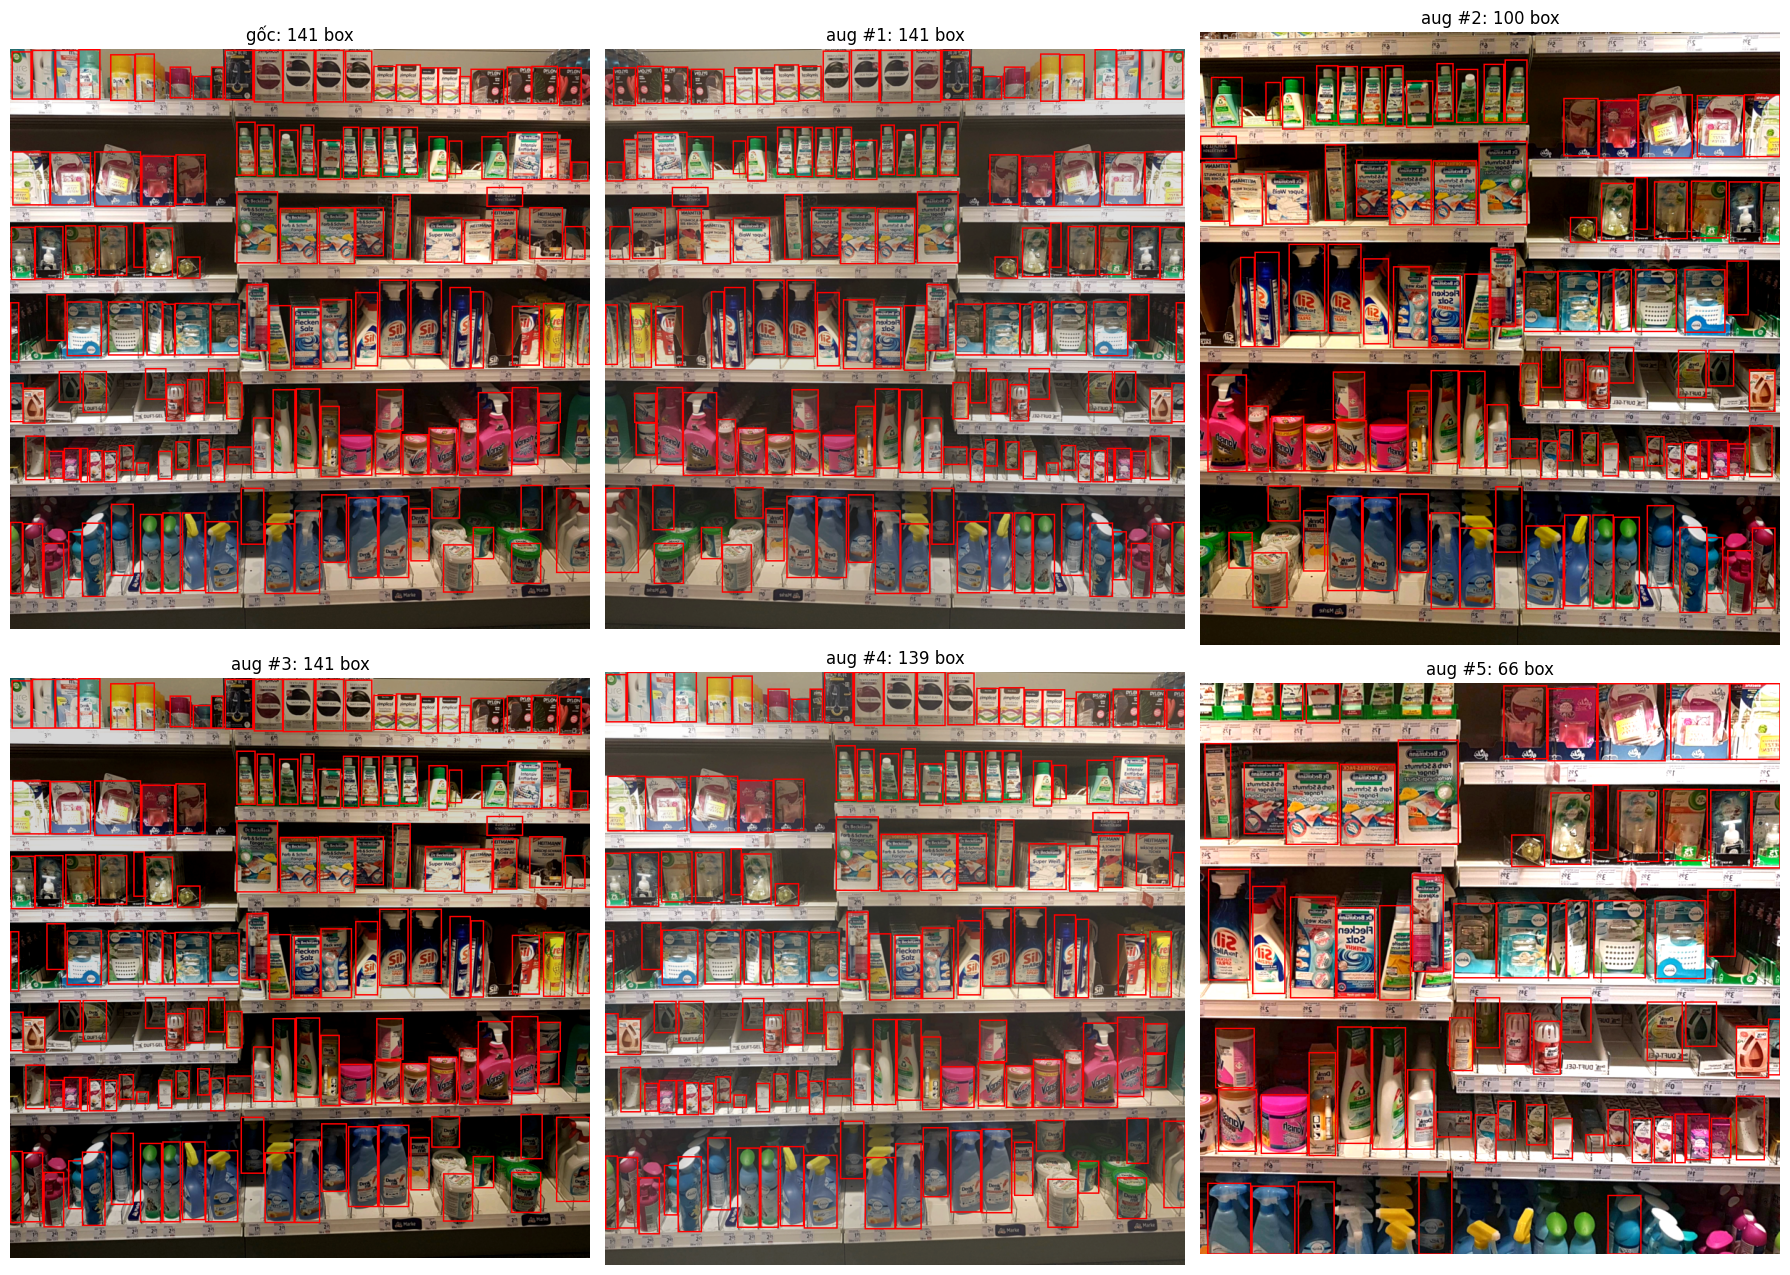

In [5]:
def draw_boxes(t, boxes, width=2):
    im = TF.to_pil_image(t)
    d = ImageDraw.Draw(im)
    for b in boxes.tolist():
        d.rectangle(b, outline=(255, 0, 0), width=width)
    return im

def show_aug(idx=0, aug=None, seed=None):
    if seed is not None:
        random.seed(seed)
    plain = SKU110KDataset(ROOT, "train", False, None, CFG["min_size"], CFG["max_size"])
    augd = SKU110KDataset(ROOT, "train", True, aug or AUG, CFG["min_size"], CFG["max_size"])
    fig, axes = plt.subplots(2, 3, figsize=(18, 13))
    img, tg = plain[idx]
    axes[0, 0].imshow(draw_boxes(img, tg["boxes"])); axes[0, 0].set_title(f"gốc: {len(tg['boxes'])} box")
    for k, ax in enumerate(axes.flat[1:]):
        img, tg = augd[idx]
        ax.imshow(draw_boxes(img, tg["boxes"])); ax.set_title(f"aug #{k+1}: {len(tg['boxes'])} box")
    for ax in axes.flat: ax.axis("off")
    plt.tight_layout(); plt.show()

show_aug(idx=0, seed=1)      # đổi idx / seed để xem ảnh khác

## 3. Model
### 3.1 Soft-IoU head
Nhánh conv phụ dự đoán IoU giữa box dự đoán và ground-truth cho từng anchor.

In [6]:
def pairwise_iou(a, b):
    """IoU từng cặp (a[i], b[i])."""
    lt = torch.max(a[:, :2], b[:, :2])
    rb = torch.min(a[:, 2:], b[:, 2:])
    inter = (rb - lt).clamp(min=0).prod(1)
    area_a = (a[:, 2:] - a[:, :2]).clamp(min=0).prod(1)
    area_b = (b[:, 2:] - b[:, :2]).clamp(min=0).prod(1)
    return inter / (area_a + area_b - inter + 1e-9)


class SoftIoUHead(RetinaNetHead):
    """RetinaNetHead (cls + box) + nhánh dự đoán Soft-IoU: với mỗi anchor, ước lượng IoU
    giữa box dự đoán và ground-truth (Goldman et al. 2019)."""

    def __init__(self, in_channels, num_anchors, num_classes):
        super().__init__(in_channels, num_anchors, num_classes)
        layers = []
        for _ in range(4):
            layers += [nn.Conv2d(in_channels, in_channels, 3, padding=1), nn.ReLU(inplace=True)]
        layers.append(nn.Conv2d(in_channels, num_anchors, 3, padding=1))
        self.iou_tower = nn.Sequential(*layers)
        for m in self.iou_tower.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        out = super().forward(x)  # {"cls_logits": (N,HWA,K), "bbox_regression": (N,HWA,4)}
        ious = []
        for f in x:
            o = self.iou_tower(f)  # (N, A, H, W)
            n, a, h, w = o.shape
            ious.append(o.permute(0, 2, 3, 1).reshape(n, h * w * a))  # cùng thứ tự với regression head
        out["soft_iou"] = torch.cat(ious, dim=1)
        return out

### 3.2 EM-Merger (xấp xỉ)
Thay NMS lúc suy luận: gộp box trùng bằng EM trên hỗn hợp Gaussian nhưng không xoá vật thể sát nhau. Không cần huấn luyện. *Đây là bản xấp xỉ, không phải bản gốc của Goldman et al.*

In [7]:
def _cxcywh(b):
    wh = b[:, 2:] - b[:, :2]
    return b[:, :2] + wh / 2, wh


@torch.no_grad()
def em_merge(boxes, scores, seed_iou=0.7, sigma_scale=0.25, iters=8, dedup_iou=0.7,
             max_candidates=4000, min_count=0.5):
    """Bản XẤP XỈ của EM-Merger.
    - Mỗi box ứng viên -> 1 Gaussian 2D (tâm = tâm box, sigma = sigma_scale * (w,h)), trọng số = score.
    - Khởi tạo các thành phần từ NMS "lỏng" (seed_iou cao), rồi chạy EM để hợp nhất các box trùng
      nhưng KHÔNG xoá các vật thể sát nhau (khác với NMS thông thường).
    - Score của thành phần = max(responsibility * score)."""
    if boxes.numel() == 0:
        return boxes, scores
    if scores.numel() > max_candidates:
        scores, top = scores.topk(max_candidates)
        boxes = boxes[top]
    seeds = box_ops.nms(boxes, scores, seed_iou)
    c, wh_i = _cxcywh(boxes)
    mu, wh = c[seeds].clone(), wh_i[seeds].clone()
    pi = torch.full((len(seeds),), 1.0 / len(seeds), device=boxes.device)

    def e_step(mu, wh, pi):
        sig = (wh * sigma_scale).clamp(min=1.0)
        d = (c[:, None, :] - mu[None]) / sig[None]
        logp = torch.log(pi + 1e-12)[None] - torch.log(sig).sum(1)[None] - 0.5 * (d * d).sum(-1)
        return torch.softmax(logp, dim=1)  # (N, K)

    for _ in range(iters):
        r = e_step(mu, wh, pi)
        w = r * scores[:, None]
        mass = w.sum(0).clamp(min=1e-6)
        mu = (w.t() @ c) / mass[:, None]
        wh = (w.t() @ wh_i) / mass[:, None]
        pi = mass / mass.sum()

    r = e_step(mu, wh, pi)
    comp_score = (r * scores[:, None]).max(0).values
    out = torch.cat([mu - wh / 2, mu + wh / 2], dim=1)
    keep = r.sum(0) > min_count
    out, comp_score = out[keep], comp_score[keep]
    if out.numel() == 0:
        return out, comp_score
    k2 = box_ops.nms(out, comp_score, dedup_iou)  # chỉ khử các thành phần đã hội tụ về cùng 1 chỗ
    return out[k2], comp_score[k2]

### 3.3 RetinaNet + loss Soft-IoU + hậu xử lý + `build_model`

In [23]:
class SoftIoURetinaNet(RetinaNet):
    def __init__(self, *args, hard_rate=0.5, soft_iou_weight=1.0, merge="em",
                 final_score_thresh=0.35, **kwargs):
        super().__init__(*args, **kwargs)
        self.hard_rate = hard_rate                  # 0.5 như bài báo; =1.0 -> chỉ dùng cls score
        self.soft_iou_weight = soft_iou_weight
        self.merge = merge                          # "em" | "nms"
        self.final_score_thresh = final_score_thresh
        self.em_kwargs = {}

    # ---- loss ---------------------------------------------------------------
    def compute_loss(self, targets, head_outputs, anchors):
        matched_idxs = []
        for anc, t in zip(anchors, targets):
            if t["boxes"].numel() == 0:
                matched_idxs.append(torch.full((anc.size(0),), -1, dtype=torch.int64, device=anc.device))
                continue
            matched_idxs.append(self.proposal_matcher(box_ops.box_iou(t["boxes"], anc)))
        losses = self.head.compute_loss(targets, head_outputs, anchors, matched_idxs)

        iou_losses = []
        for t, reg, siou, anc, midx in zip(targets, head_outputs["bbox_regression"],
                                           head_outputs["soft_iou"], anchors, matched_idxs):
            fg = midx >= 0
            n_fg = int(fg.sum())
            if n_fg == 0:
                iou_losses.append(siou.sum() * 0.0)
                continue
            with torch.no_grad():
                pred = self.box_coder.decode_single(reg[fg], anc[fg])
                target = pairwise_iou(pred, t["boxes"][midx[fg]])
            iou_losses.append(nn.functional.binary_cross_entropy_with_logits(
                siou[fg], target, reduction="sum") / n_fg)
        losses["soft_iou"] = self.soft_iou_weight * torch.stack(iou_losses).mean()
        return losses

    # ---- inference ----------------------------------------------------------
    @torch.no_grad()
    def postprocess_detections(self, split_head_outputs, split_anchors, image_shapes):
        results = []
        for i, shape in enumerate(image_shapes):
            all_b, all_s = [], []
            for cls_l, reg_l, iou_l, anc_l in zip(split_head_outputs["cls_logits"],
                                                  split_head_outputs["bbox_regression"],
                                                  split_head_outputs["soft_iou"], split_anchors[i]):
                hard = torch.sigmoid(cls_l[i]).flatten()
                soft = torch.sigmoid(iou_l[i])
                score = hard ** self.hard_rate * soft ** (1.0 - self.hard_rate)
                idx = torch.where(score > self.score_thresh)[0]
                if idx.numel() == 0:
                    continue
                sc, order = score[idx].topk(min(self.topk_candidates, idx.numel()))
                idx = idx[order]
                b = self.box_coder.decode_single(reg_l[i][idx], anc_l[idx])
                all_b.append(box_ops.clip_boxes_to_image(b, shape))
                all_s.append(sc)
            if not all_b:
                dev = split_anchors[i][0].device
                results.append({"boxes": torch.zeros((0, 4), device=dev), "scores": torch.zeros(0, device=dev),
                                "labels": torch.zeros(0, dtype=torch.int64, device=dev)})
                continue
            boxes, scores = torch.cat(all_b), torch.cat(all_s)
            if self.merge == "em":
                boxes, scores = em_merge(boxes, scores, **self.em_kwargs)
                boxes = box_ops.clip_boxes_to_image(boxes, shape)
            else:
                k = box_ops.nms(boxes, scores, self.nms_thresh)
                boxes, scores = boxes[k], scores[k]
            k = scores > self.final_score_thresh
            boxes, scores = boxes[k], scores[k]
            order = scores.argsort(descending=True)[: self.detections_per_img]
            boxes, scores = boxes[order], scores[order]
            results.append({"boxes": boxes, "scores": scores,
                            "labels": torch.zeros(len(boxes), dtype=torch.int64, device=boxes.device)})
        return results

    def forward(self, images, targets=None):
        original_sizes = [tuple(img.shape[-2:]) for img in images]
        images, targets = self.transform(images, targets)
        feats = self.backbone(images.tensors)
        feats = list(feats.values()) if not isinstance(feats, torch.Tensor) else [feats]
        head_outputs = {k: v.float() for k, v in self.head(feats).items()}
        anchors = [a.float() for a in self.anchor_generator(images, feats)]

        if self.training:
            return self.compute_loss(targets, head_outputs, anchors)

        n_per_level = [f.size(2) * f.size(3) for f in feats]
        A = head_outputs["cls_logits"].size(1) // sum(n_per_level)
        n_per_level = [n * A for n in n_per_level]
        split_out = {k: list(v.split(n_per_level, dim=1)) for k, v in head_outputs.items()}
        split_anc = [list(a.split(n_per_level)) for a in anchors]
        dets = self.postprocess_detections(split_out, split_anc, images.image_sizes)
        return self.transform.postprocess(dets, images.image_sizes, original_sizes)


def make_anchor_generator(bases):
    assert len(bases) == 5, "cần đúng 5 mức anchor (P3..P7)"
    sizes = tuple((b, int(b * 2 ** (1 / 3)), int(b * 2 ** (2 / 3))) for b in bases)
    return AnchorGenerator(sizes, ((0.5, 1.0, 2.0),) * len(sizes))


def build_model(cfg, pretrained=True):
    """cfg: dict/Namespace-like. init = 'imagenet' | 'coco' | 'none'."""
    g = lambda k, d=None: cfg.get(k, d) if isinstance(cfg, dict) else getattr(cfg, k, d)  # noqa
    init = g("init", "imagenet") if pretrained else "none"
    body = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1 if init == "imagenet" else None,
                    norm_layer=FrozenBatchNorm2d)
    backbone = _resnet_fpn_extractor(body, g("trainable_layers", 3), returned_layers=[2, 3, 4],
                                     extra_blocks=LastLevelP6P7(256, 256))
    ag = make_anchor_generator(g("anchor_sizes", [32, 64, 128, 256, 512]))
    head = SoftIoUHead(backbone.out_channels, ag.num_anchors_per_location()[0], num_classes=1)
    model = SoftIoURetinaNet(
        backbone, num_classes=1, min_size=g("min_size", 800), max_size=g("max_size", 1333),
        anchor_generator=ag, head=head, score_thresh=0.05, nms_thresh=0.5,
        detections_per_img=g("max_det", 1000), topk_candidates=g("topk", 2000),
        hard_rate=g("hard_rate", 0.5),
        soft_iou_weight=0.0 if g("no_soft_iou", False) else g("soft_iou_weight", 1.0),
        merge="nms" if g("no_soft_iou", False) else g("merge", "em"),
        final_score_thresh=g("final_thresh", 0.35))
    if g("no_soft_iou", False):
        model.hard_rate = 1.0
    if init == "coco":  # backbone + FPN + tháp conv của head; bỏ lớp cls cuối (khác số lớp)
        coco = retinanet_resnet50_fpn(weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1).state_dict()
        sd = {k: v for k, v in coco.items()
              if k.startswith("backbone.") or k.startswith("head.regression_head.")
              or k.startswith("head.classification_head.conv.")}
        print("load COCO:", model.load_state_dict(sd, strict=False))
    return model

### 3.4 Kiểm tra nhanh (sanity check)
Chạy 1 batch forward + backward để chắc model/dataset/loss hoạt động trước khi train dài. Chưa train nên số box phát hiện có thể bằng 0 (bình thường).

In [9]:
# _model = build_model(CFG).to(device)
# _ds = SKU110KDataset(ROOT, "train", True, AUG, CFG["min_size"], CFG["max_size"], max_images=8)
# _images, _targets = next(iter(DataLoader(_ds, 2, collate_fn=collate)))
# _images = [i.to(device) for i in _images]
# _targets = [{k: v.to(device) for k, v in t.items()} for t in _targets]

# _model.train()
# _losses = _model(_images, _targets)
# print({k: round(v.item(), 4) for k, v in _losses.items()})
# sum(_losses.values()).backward()
# print("backward OK")
# if device.type == "cuda":
#     print(f"GPU mem: {torch.cuda.max_memory_allocated()/1e9:.1f} GB")

# _model.eval()
# with torch.no_grad():
#     _out = _model(_images)
# print("số box/ảnh:", [len(o["boxes"]) for o in _out])
# del _model, _ds, _images, _targets, _losses, _out
# torch.cuda.empty_cache()

## 4. Hàm đánh giá
AP kiểu COCO (AP, AP50, AP75) và MAE/RMSE của số lượng vật thể — như Bảng 2 trong bài báo.

In [10]:
def iou_np(a, b):
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[..., 0] * wh[..., 1]
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    ab = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (aa[:, None] + ab[None] - inter + 1e-9)


def compute_ap(preds, gts, thr):
    all_s, all_tp, n_gt = [], [], 0
    for (pb, ps), gb in zip(preds, gts):
        n_gt += len(gb)
        if len(pb) == 0:
            continue
        o = np.argsort(-ps)
        pb, ps = pb[o], ps[o]
        tp = np.zeros(len(pb))
        if len(gb):
            ious = iou_np(pb, gb)
            used = np.zeros(len(gb), bool)
            for i in range(len(pb)):
                row = np.where(used, -1.0, ious[i])
                j = int(row.argmax())
                if row[j] >= thr:
                    used[j], tp[i] = True, 1
        all_s.append(ps)
        all_tp.append(tp)
    if not all_s or n_gt == 0:
        return 0.0
    s, tp = np.concatenate(all_s), np.concatenate(all_tp)
    tp = tp[np.argsort(-s)]
    tpc, fpc = np.cumsum(tp), np.cumsum(1 - tp)
    rec, prec = tpc / n_gt, tpc / np.maximum(tpc + fpc, 1e-9)
    prec = np.maximum.accumulate(prec[::-1])[::-1]
    inds = np.searchsorted(rec, np.linspace(0, 1, 101), side="left")
    q = np.array([prec[i] if i < len(prec) else 0.0 for i in inds])
    return float(q.mean())


@torch.no_grad()
def evaluate(model, loader, device, count_thresh=0.35, low_thresh=0.05):
    model.eval()
    old = model.final_score_thresh
    model.final_score_thresh = low_thresh  # AP cần cả các box điểm thấp
    preds, gts = [], []
    for images, targets in loader:
        outs = model([im.to(device) for im in images])
        for o, t in zip(outs, targets):
            preds.append((o["boxes"].cpu().numpy(), o["scores"].cpu().numpy()))
            gts.append(t["boxes"].numpy())
    model.final_score_thresh = old
    aps = {t: compute_ap(preds, gts, t) for t in np.arange(0.5, 0.96, 0.05).round(2)}
    cnt_err = np.array([(ps >= count_thresh).sum() - len(g) for (_, ps), g in zip(preds, gts)], float)
    return {"AP": float(np.mean(list(aps.values()))), "AP50": aps[0.5], "AP75": aps[0.75],
            "MAE": float(np.abs(cnt_err).mean()), "RMSE": float(np.sqrt((cnt_err ** 2).mean()))}

## 5. Huấn luyện
### 5.1 Hàm train + lưu/nạp checkpoint

In [11]:
def save_ckpt(path, model, cfg, **extra):
    torch.save({"model": model.state_dict(), "cfg": cfg, **extra}, path)

def load_ckpt(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

def model_from_ckpt(path, dev, overrides=None):
    ck = load_ckpt(path)
    cfg = dict(ck["cfg"])
    cfg.update({k: v for k, v in (overrides or {}).items() if v is not None})
    model = build_model(cfg, pretrained=False)
    model.load_state_dict(ck["model"])
    return model.to(dev).eval(), cfg


def train_run(cfg, aug, out_dir, resume=None):
    """Có early stopping theo val AP. Trả về history."""
    cfg = dict(cfg)
    patience, min_delta = cfg.get("patience", 0), cfg.get("min_delta", 0.0)
    torch.manual_seed(cfg["seed"]); random.seed(cfg["seed"]); np.random.seed(cfg["seed"])
    out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)

    ds_tr = SKU110KDataset(ROOT, "train", True, aug, cfg["min_size"], cfg["max_size"], cfg["max_train_images"])
    ds_va = SKU110KDataset(ROOT, "val", False, None, cfg["min_size"], cfg["max_size"], cfg["val_images"])
    dl_tr = DataLoader(ds_tr, cfg["batch_size"], shuffle=True, num_workers=cfg["workers"],
                       collate_fn=collate, drop_last=True, pin_memory=True)
    dl_va = DataLoader(ds_va, 2, shuffle=False, num_workers=cfg["workers"], collate_fn=collate)
    print(f"[{out.name}] train {len(ds_tr)} ảnh | val {len(ds_va)} ảnh | patience={patience} | aug={aug}")

    model = build_model(cfg).to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.SGD(params, lr=cfg["lr"], momentum=0.9, weight_decay=1e-4)
    total = cfg["epochs"] * len(dl_tr)
    warm = min(500, total // 10 + 1)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda it: ((it + 1) / warm if it < warm else 1.0) * max(0.5 * (1 + math.cos(math.pi * it / total)), 0.01))
    use_amp = cfg["amp"] and device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    start, best_ap, history, bad = 0, -1.0, [], 0
    if resume:
        ck = load_ckpt(resume)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"]); sched.load_state_dict(ck["sched"])
        start, best_ap = ck["epoch"] + 1, ck.get("best_ap", -1.0)
        hp = out / "history.json"
        history = json.load(open(hp)) if hp.exists() else []
        if history:  # khôi phục bộ đếm early stopping
            best_idx = max(range(len(history)), key=lambda i: history[i]["val_AP"])
            bad = len(history) - 1 - best_idx
        print("resume từ epoch", start, "| bad =", bad)

    for epoch in range(start, cfg["epochs"]):
        model.train()
        t0, run, n = time.time(), {}, 0
        for it, (images, targets) in enumerate(dl_tr):
            images = [im.to(device, non_blocking=True) for im in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            with torch.cuda.amp.autocast(enabled=use_amp):
                losses = model(images, targets)
            loss = sum(losses.values())
            opt.zero_grad(set_to_none=True)
            if not torch.isfinite(loss):
                print("[warn] loss không hữu hạn -> bỏ batch"); sched.step(); continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(params, 10.0)
            scaler.step(opt); scaler.update(); sched.step()
            n += 1
            for k, v in losses.items():
                run[k] = run.get(k, 0.0) + v.item()
            if (it + 1) % cfg["log_every"] == 0:
                print(f"ep {epoch+1}/{cfg['epochs']} it {it+1}/{len(dl_tr)} lr={opt.param_groups[0]['lr']:.5f} "
                      + " ".join(f"{k}={v/n:.4f}" for k, v in run.items()) + f" | {time.time()-t0:.0f}s", flush=True)
        m = evaluate(model, dl_va, device)
        rec = {"epoch": epoch + 1, **{k: v / max(n, 1) for k, v in run.items()}, **{"val_" + k: v for k, v in m.items()}}
        history.append(rec)
        json.dump(history, open(out / "history.json", "w"))
        print("== " + " ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" for k, v in rec.items()), flush=True)

        # ---- early stopping ----
        if m["AP"] > best_ap + min_delta:
            best_ap, bad = m["AP"], 0
            save_ckpt(out / "best.pth", model, cfg, aug=aug, epoch=epoch, best_ap=best_ap)
            print(f"   ↑ val AP cải thiện -> lưu best.pth ({best_ap:.4f})")
        else:
            bad += 1
            print(f"   không cải thiện ({bad}/{patience})")
        torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(),
                    "cfg": cfg, "aug": aug, "epoch": epoch, "best_ap": best_ap}, out / "last.pth")
        if patience > 0 and bad >= patience:
            print(f"Early stopping tại epoch {epoch + 1}: {patience} epoch liên tiếp không cải thiện.")
            break
    print(f"[{out.name}] xong. best val AP = {best_ap:.4f}")
    return history

## 5.* chạy để check số epochs đã train từ file checkpoint đã tải về

In [12]:
import os, shutil, json, torch

# tìm đường dẫn thật của dataset checkpoint
for root, dirs, files in os.walk("/kaggle/input"):
    if "last.pth" in files:
        print("Tìm thấy:", root)
        SRC = root

# /kaggle/input là chỉ-đọc -> copy sang /kaggle/working/run1 để train_run ghi tiếp được
os.makedirs(OUT, exist_ok=True)
for f in ["last.pth", "best.pth", "history.json"]:
    shutil.copy(f"{SRC}/{f}", f"{OUT}/{f}")

ck = torch.load(OUT + "/last.pth", map_location="cpu", weights_only=False)
print(f"Đã xong {ck['epoch'] + 1} epoch | best val AP = {ck['best_ap']:.4f}")
print("CFG lúc train:", {k: ck["cfg"].get(k) for k in ["epochs", "batch_size", "lr", "max_train_images"]})

for r in json.load(open(OUT + "/history.json")):
    print(r["epoch"], "val_AP=%.4f  AP50=%.4f  MAE=%.2f" % (r["val_AP"], r["val_AP50"], r["val_MAE"]))

# dùng lại đúng cấu hình cũ để lịch LR không bị lệch
CFG = dict(ck["cfg"])
AUG = ck["aug"]
CFG["patience"] = 3        # bản checkpoint cũ có thể chưa có early stopping
CFG["min_delta"] = 0.001
CFG["init"] = "none"       # trọng số lấy từ checkpoint, khỏi tải ImageNet

Tìm thấy: /kaggle/input/datasets/phongkaggle/sku110k-ckpt
Đã xong 6 epoch | best val AP = 0.3856
CFG lúc train: {'epochs': 20, 'batch_size': 4, 'lr': 0.0025, 'max_train_images': None}
1 val_AP=0.2893  AP50=0.6061  MAE=90.78
2 val_AP=0.3328  AP50=0.6385  MAE=73.89
3 val_AP=0.3572  AP50=0.6695  MAE=65.76
4 val_AP=0.3733  AP50=0.6883  MAE=69.45
5 val_AP=0.3723  AP50=0.6728  MAE=68.06
6 val_AP=0.3856  AP50=0.6882  MAE=59.78


### 5.3 Train đầy đủ
Chọn `AUG` hoặc `AUG_OFF` theo kết quả A/B. Nếu session Kaggle bị ngắt: đặt `resume=OUT + '/last.pth'`.

In [13]:
# history = train_run(CFG, AUG, OUT, resume=None)   # train từ đầu 

In [14]:
history = train_run(CFG, AUG, OUT, resume=OUT + "/last.pth") # train từ checkpoint đã lưu 

[run1] train 8219 ảnh | val 200 ảnh | patience=3 | aug={'hflip': 0.5, 'zoom_p': 0.5, 'zoom_range': (0.6, 1.0), 'min_visible': 0.5, 'color_p': 0.8, 'brightness': 0.3, 'contrast': 0.3, 'saturation': 0.3, 'hue': 0.02, 'blur_p': 0.1}


/tmp/ipykernel_58/292555615.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


resume từ epoch 6 | bad = 0


/tmp/ipykernel_58/292555615.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


ep 7/20 it 50/2054 lr=0.00198 classification=0.1460 bbox_regression=0.2686 soft_iou=0.4922 | 41s
ep 7/20 it 100/2054 lr=0.00198 classification=0.1395 bbox_regression=0.2621 soft_iou=0.4884 | 78s
ep 7/20 it 150/2054 lr=0.00197 classification=0.1364 bbox_regression=0.2587 soft_iou=0.4876 | 115s
[warn] lỗi đọc train_882.jpg: image file is truncated (3 bytes not processed)
[warn] lỗi đọc train_4222.jpg: image file is truncated (23 bytes not processed)
ep 7/20 it 200/2054 lr=0.00197 classification=0.1346 bbox_regression=0.2566 soft_iou=0.4865 | 153s
ep 7/20 it 250/2054 lr=0.00197 classification=0.1352 bbox_regression=0.2575 soft_iou=0.4869 | 191s
ep 7/20 it 300/2054 lr=0.00196 classification=0.1372 bbox_regression=0.2572 soft_iou=0.4869 | 227s
ep 7/20 it 350/2054 lr=0.00196 classification=0.1373 bbox_regression=0.2579 soft_iou=0.4880 | 263s
ep 7/20 it 400/2054 lr=0.00195 classification=0.1355 bbox_regression=0.2573 soft_iou=0.4875 | 301s
ep 7/20 it 450/2054 lr=0.00195 classification=0.1353 

In [ ]:
train tiếp nếu bị dừng chạy cell này 
import os
ck = OUT + "/last.pth"
print("last.pth tồn tại:", os.path.exists(ck))
history = train_run(CFG, AUG, OUT, resume=ck if os.path.exists(ck) else None)

## 6. Kết quả
### 6.1 Đường cong train / val

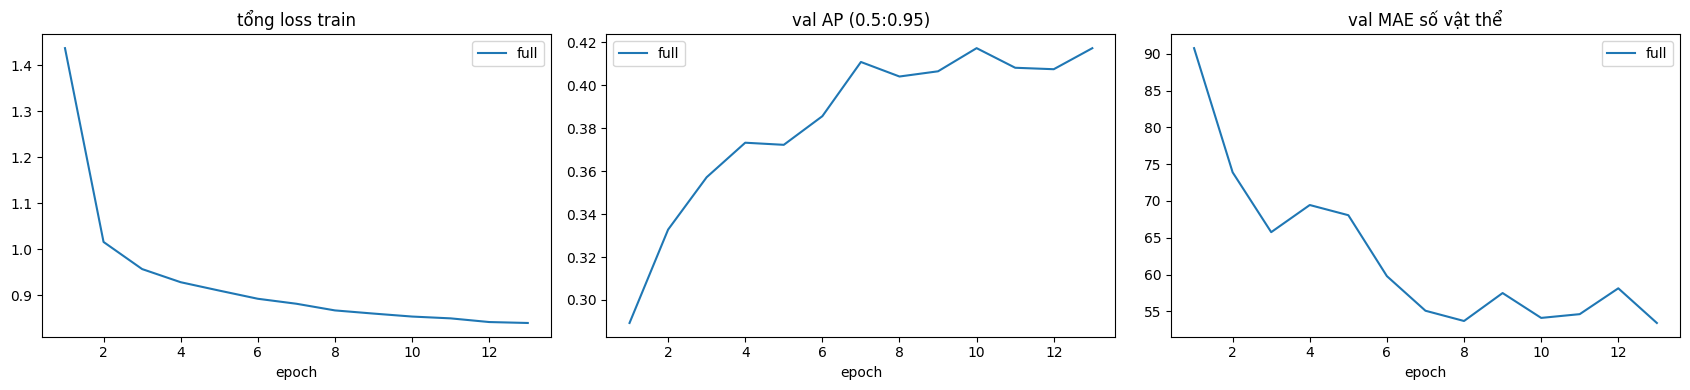

In [16]:
def plot_history(hists):
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    for name, h in hists.items():
        ep = [r["epoch"] for r in h]
        ax[0].plot(ep, [r.get("classification", 0) + r.get("bbox_regression", 0) + r.get("soft_iou", 0) for r in h], label=name)
        ax[1].plot(ep, [r["val_AP"] for r in h], label=name)
        ax[2].plot(ep, [r["val_MAE"] for r in h], label=name)
    for a, t in zip(ax, ["tổng loss train", "val AP (0.5:0.95)", "val MAE số vật thể"]):
        a.set_title(t); a.set_xlabel("epoch"); a.legend()
    plt.tight_layout(); plt.show()

plot_history({"full": history})      # hoặc {"chỉ hflip": hist_off, "đầy đủ aug": hist_on}

### 6.2 Đánh giá trên tập test: NMS vs EM-Merger
Cùng một checkpoint, chỉ đổi bước hậu xử lý.

In [24]:
dl_te = DataLoader(SKU110KDataset(ROOT, "test", False, None, CFG["min_size"], CFG["max_size"]),
                   2, shuffle=False, num_workers=CFG["workers"], collate_fn=collate)
for merge in ["nms", "em"]:
    model, _ = model_from_ckpt(OUT + "/best.pth", device, {"merge": merge})
    m = evaluate(model, dl_te, device)
    print(f"{merge:4s}", " ".join(f"{k}={v:.4f}" for k, v in m.items()))

nms  AP=0.4923 AP50=0.8191 AP75=0.5490 MAE=33.7592 RMSE=47.5389
em   AP=0.4540 AP50=0.7768 AP75=0.4920 MAE=40.8862 RMSE=57.2983


### 6.3 Dự đoán trên 1 ảnh (NMS vs EM cạnh nhau)

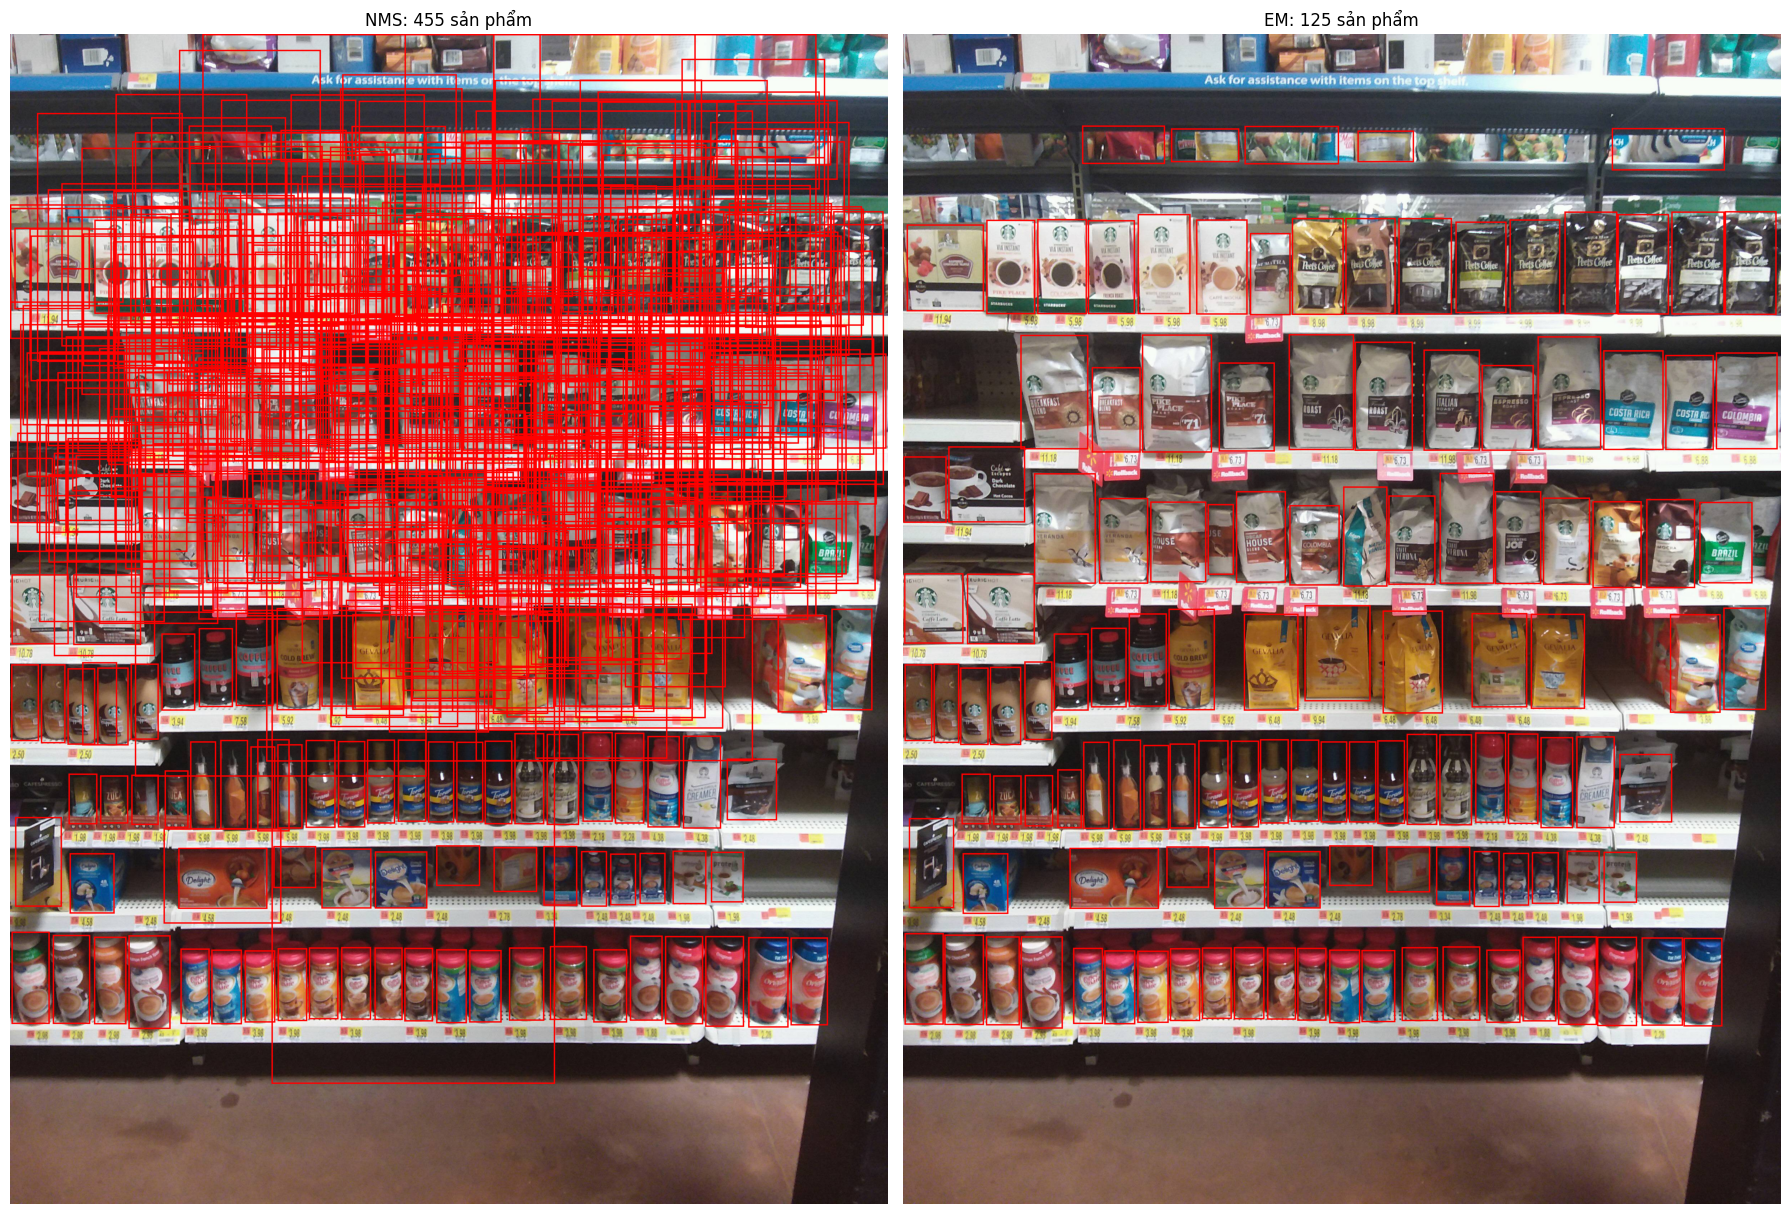

In [18]:
@torch.no_grad()
def predict_compare(path, ckpt=OUT + "/best.pth", thresh=0.35):
    model, _ = model_from_ckpt(ckpt, device, {"final_thresh": thresh})
    img = Image.open(path).convert("RGB")
    x = TF.to_tensor(img).to(device)
    fig, axes = plt.subplots(1, 2, figsize=(18, 12))
    for ax, merge in zip(axes, ["nms", "em"]):
        model.merge = merge
        boxes = model([x])[0]["boxes"].cpu()
        ax.imshow(draw_boxes(TF.to_tensor(img), boxes, width=max(1, img.width // 600)))
        ax.set_title(f"{merge.upper()}: {len(boxes)} sản phẩm"); ax.axis("off")
    plt.tight_layout(); plt.show()

predict_compare(f"{ROOT}/images/test_0.jpg")